# Context of the project :
The goal of this project is to create a `supervised classifier IA model` who can predict if a data is in a class or not. The choice of the dataset was free (*as long as the data come from the medical field*), so we choose to work with a dataset of **X-rays images of fractured and not fractured hand and wrist**.

> `Supervised learning `is a type of machine learning where the model is trained on a labeled dataset, meaning that each input data point is associated with a corresponding output label. The model learns to map the input data to the correct output labels during the training process, allowing it to make predictions on new, unseen data.

> `Classification` is a type of supervised learning where the goal is to predict the class label of a given input based on its features. *In this case, the model will learn to classify X-ray images as either "fractured" or "not fractured" based on the patterns and features present in the images.*

## The dataset :
**10 000 images of X-rays images of fractured and not fractured hand and wrist**

Why this dataset ? Because it is a good example of a binary classification problem, and it is a real-world problem that can have a significant impact on the medical field. The model can help doctors to quickly and accurately diagnose fractures, which can lead to better patient outcomes. *Furthermore, some of us are familiar with this type of injury.*

**Sources :**
> https://www.kaggle.com/datasets/osamajalilhassan/bone-fracture-dataset/data



- 2 folders : one with fractured hand and wrist, and one with not fractured hand and wrist
- Each folder contains images of hand and wrist X-rays, with the same format (jpg)
- The dataset is balanced, with the same number of images in each folder

**How to detect fractures ?**

> By definition, a fracture is a break in a bone. On an X-ray, it is necessary to detect abnormalities in the bone, look for fracture lines, check the continuity of the bone and/or look for bone displacement.


## 1. Dataset Exploration and Visualization

**Import libraries `matplotlib`, `seaborn` and `os` to explore and visualize the dataset**

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import pandas as pd

**First lets see examples of X-rays with the fracture identified to understand the difficulty of the task and to put yourself in the model's shoes.**

For this we use matplotlib.patches for display X-rays and draw a red circle on the fracture

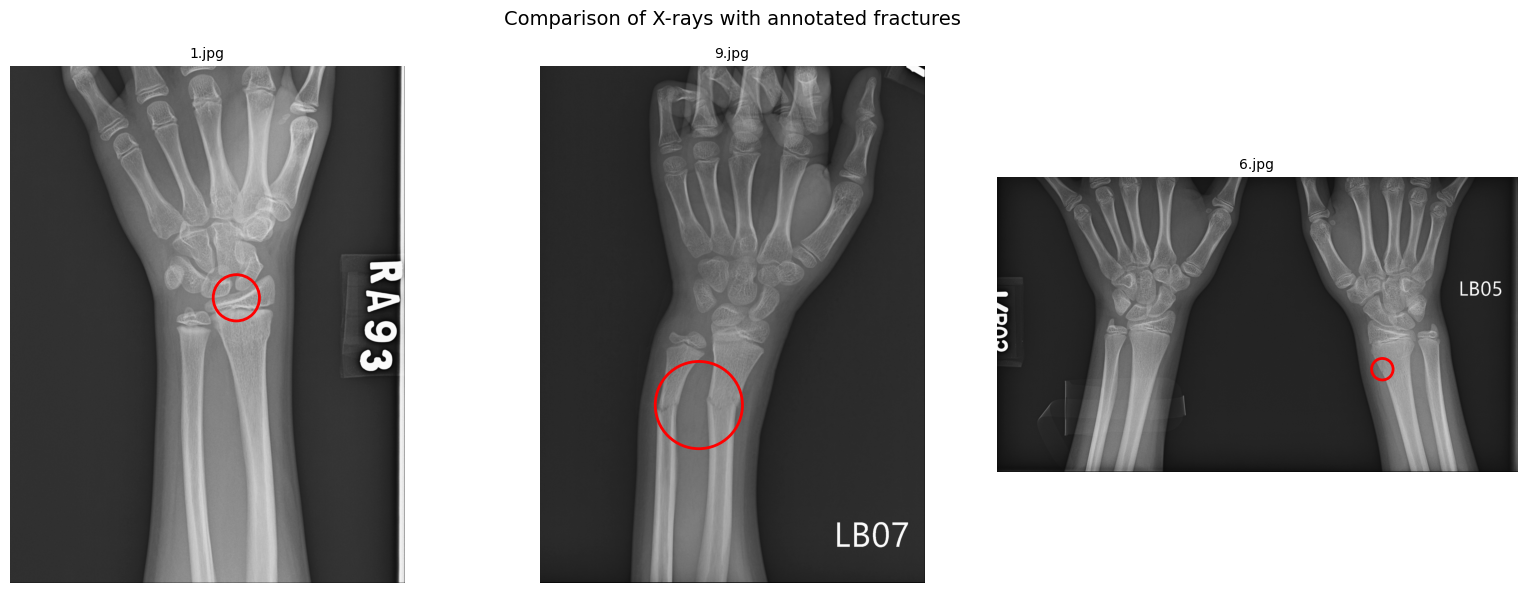

In [2]:
import matplotlib.patches as patches

def show_fracture_with_mark(ax, image_path, x, y, radius=50):
    img = plt.imread(image_path)
    ax.imshow(img, cmap='gray')
    circ = patches.Circle((x, y), radius, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(circ)
    ax.set_title(os.path.basename(image_path), fontsize=10)
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

show_fracture_with_mark(axes[0], 'Dataset/fractured/1.jpg', x=880, y=900, radius=90)
show_fracture_with_mark(axes[1], 'Dataset/fractured/9.jpg', x=620, y=1320, radius=170)
show_fracture_with_mark(axes[2], 'Dataset/fractured/6.jpg', x=2150, y=1070, radius=60)

plt.suptitle("Comparison of X-rays with annotated fractures", fontsize=14)
plt.tight_layout()
plt.show()

**Colors for the visualizations**, create a palette with the first and the last color of the list to have a good contrast between the two classes in the visualizations.

In [3]:
colors = ['#F72585', '#B5179E', '#7209B7', '#560BAD', '#480CA8', '#3A0CA3', '#3F37C9', '#4361EE', '#4895EF',
          '#4CC9F0', ]
palette = [colors[0], colors[9]]

### Repartition of the images in the dataset

**Visualize the distribution of the images in the dataset with a pie chart and a bar chart. The pie chart will show the percentage of images in each class, while the bar chart will show the exact quantity of images in each class.**

> First we retrieve the number of images in each folder using `os.listdir()` and then we create the visualizations using `matplotlib` and `seaborn` with the previous palette. We also add titles, labels and grid to make the visualizations more clear and informative.

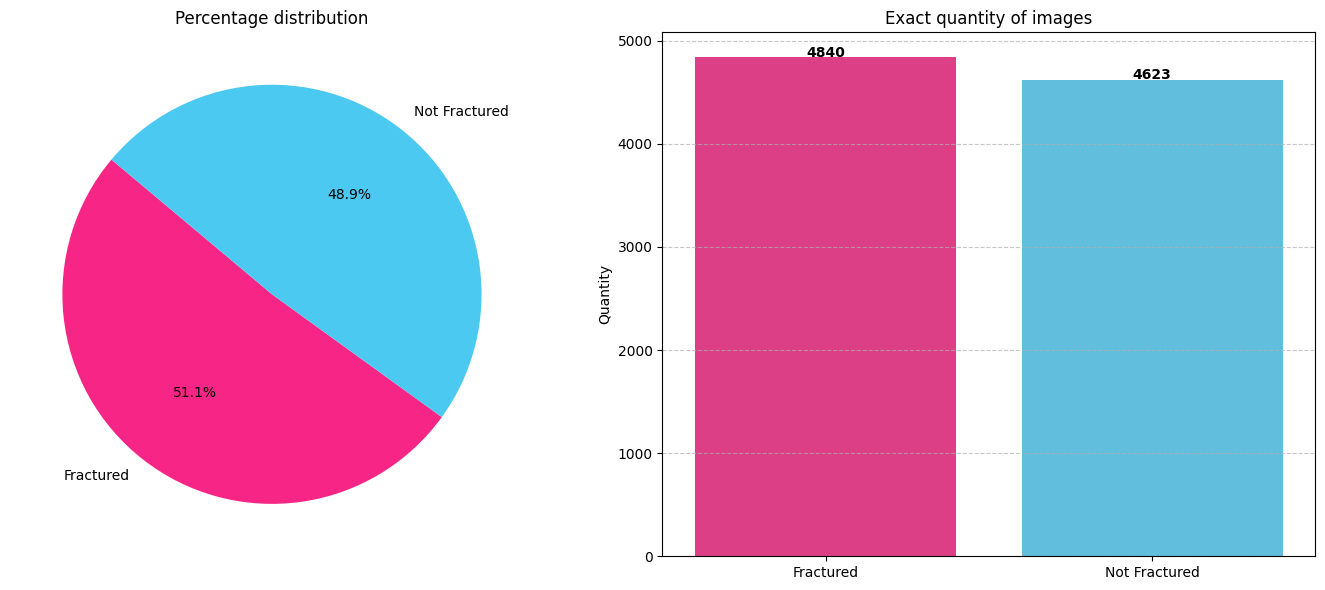

In [4]:
labels = ['Fractured', 'Not Fractured']
sizes = [len(os.listdir('Dataset/fractured/')), len(os.listdir('Dataset/not_fractured/'))]

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette(palette))
ax[0].set_title('Percentage distribution')

sns.barplot(x=labels, y=sizes, hue=labels, palette=palette, legend=False)
ax[1].set_title('Exact quantity of images')
ax[1].set_ylabel('Quantity')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(sizes):
    ax[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**Creation of a DataFrame to store the mean and standard deviation of the pixel values for each image in the dataset, along with the class label (fractured or not fractured) and the name of the image.**

> This will allow us to visualize the distribution of these features and see if there are any differences between the two classes.

In [5]:
data_list = []
for folder in ['fractured', 'not_fractured']:
    folder_path = os.path.join('Dataset', folder)
    for img_name in os.listdir(folder_path):
        try:
            img = plt.imread(os.path.join(folder_path, img_name))
            raw_mean = np.mean(img)
            if np.max(img) > 1.0:
                final_mean = raw_mean / 255.0
            else:
                final_mean = raw_mean
            data_list.append({'Name': img_name, 'Class': folder, 'Mean': final_mean, 'Std': np.std(img) / 255.0 if np.max(img) > 1.0 else np.std(img)})
        except:
            continue

df = pd.DataFrame(data_list)

**Once we have the data repartition, and a well separated dataframe, we want to see the brightness of X-rays and compare fractured and not-fractured one**

To compare the two groups and visualize the brightness of each image, we use two graphs :

> The first is a seaborn plot called violinplot, which allows us to compare the average brightness of the two groups (fractured and unfractured). The blue and pink shapes indicate the distribution of the images on the brightness scale.


> The second is also a seaborn graph, called a scatterplot. It displays all the images as points and crosses according to the average and standard brightness. It allows visualization of the initial images that appeared abnormal.

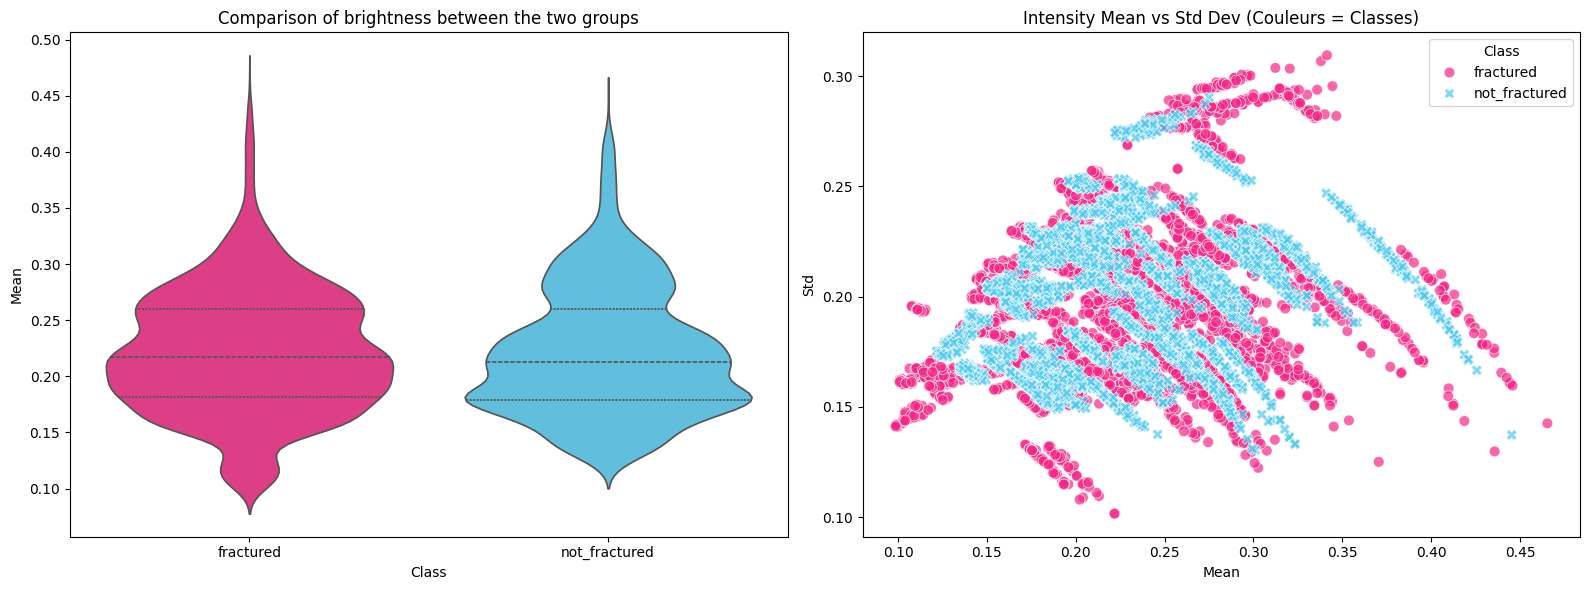

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=df, x='Class', y='Mean', inner="quartile", palette=palette, hue='Class', legend=False, ax=axes[0])
axes[0].set_title("Comparison of brightness between the two groups")

sns.scatterplot(data=df, x='Mean', y='Std', hue='Class', style='Class', palette=palette, alpha=0.7, s=60, ax=axes[1])
axes[1].set_title('Intensity Mean vs Std Dev (Couleurs = Classes)')

plt.tight_layout()
plt.show()

Thanks to these two graphs, we can see that the light spectrum of images showing a fracture is slightly broader. Furthermore, images showing a fracture can achieve high average brightness levels.
This excess of brightness is perfectly normal; it is explained by the fact that fractures can be represented as white "lines" on X-rays.
Now that we can observe that there are aberrant images in the dataset, we need more details to know if we should get rid of them.



**Added two graphs to display and identify outliers present in the dataset, a boxplot and a scatter plot with a line axial.**

<div style="display: flex; align-items: center; gap: 20px;">

<div style="flex: 1;">

**Explanation of the box plot method**

The box plot displays the distribution of data using five summary statistics:

- **Minimum** -> smallest value excluding outliers
- **First Quartile (Q1)** -> 25% of the data
- **Median (Q2)** -> middle value
- **Third Quartile (Q3)** -> 75% of the data
- **Maximum** -> largest value excluding outliers

Points outside the whiskers are considered **potential** outliers.

</div>


<div style="flex: 1;">
<img src="assets/images/boxplot_explaination.png" width="450">
</div>


</div>

*Our boxplot will be vertical*

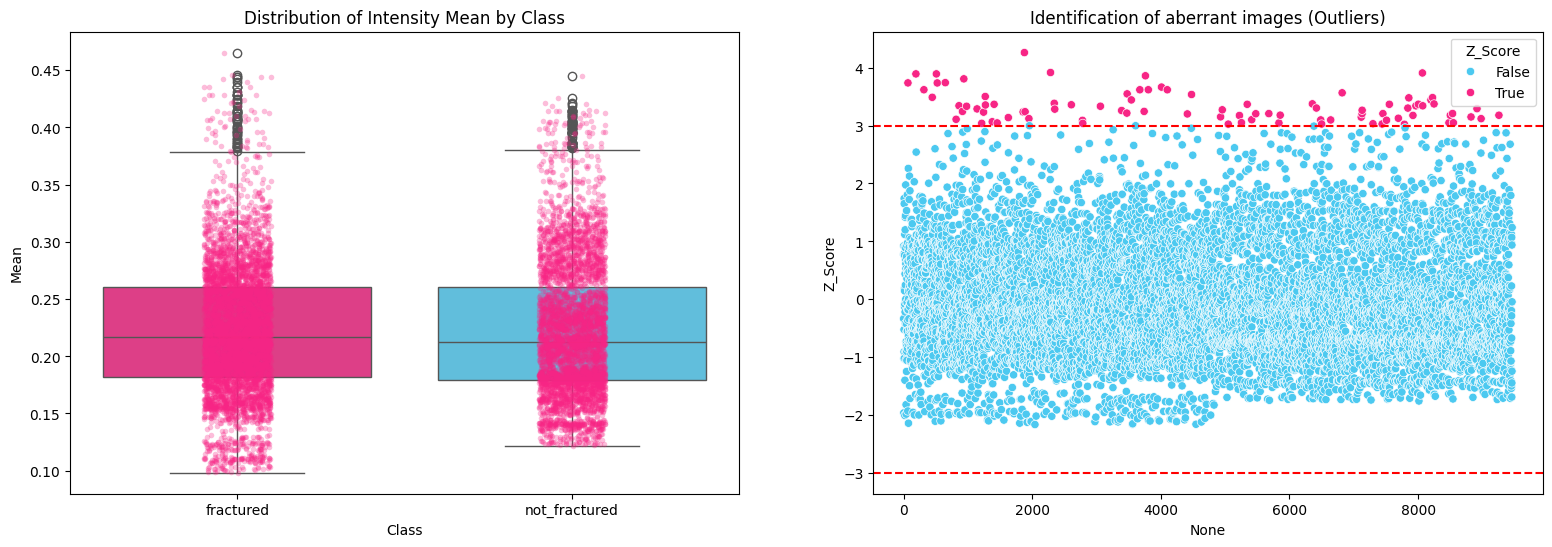

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(19, 6))

sns.boxplot(data=df, x='Class', y='Mean', hue='Class', palette=palette, ax=axes[0], legend=False)
sns.stripplot(data=df, x='Class', y='Mean', color=colors[0], alpha=0.3, size=4, ax=axes[0])
axes[0].set_title('Distribution of Intensity Mean by Class')

df['Z_Score'] = (df['Mean'] - df['Mean'].mean()) / df['Mean'].std()

sns.scatterplot(data=df, x=df.index, y='Z_Score', hue=(df['Z_Score'].abs() > 3), palette={True: palette[0], False: palette[1]}, ax=axes[1])
axes[1].axhline(3, color='red', linestyle='--')
axes[1].axhline(-3, color='red', linestyle='--')
axes[1].set_title("Identification of aberrant images (Outliers)")

plt.show()

Thanks to these visualizations, we can see that there are some outliers in the dataset. These outliers could be due to various reasons, but we must remove them to avoid biasing the model.
We can also see that the fractured data tends to have a higher mean intensity than the not fractured data, which, like we already say, is normal.

Since that normal for the fractured data to be brighter, only extremely distant images are considered as outliers (like higher than ~0.42).
For the not fractured data, we can consider as outliers the images with a mean intensity higher than 0.4/0.45, which is quite high for this class.

## 2. Data Preprocessing


### Outliers cleaning

Now that we know there are outliers in the dataframe, let's remove them. First let's import somes librairies :

**Import libraries `sklearn.pipeline` and `sklearn.preprocessing` build the pipeline**

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

**Import our own library `CvrieLib` to preprocess the images, and reload it to be sure to have the last version every time we run the code**

- *The* preprocess_image *function* __ no longer used__

- *The* flatten_image_array *function will take a 3D array of images and will flatten it into a 2D array, where each row corresponds to an image and each column corresponds to a pixel value.*

- *The* image_to_array *function which transforms all images into arrays of points.*

- *The* divide_gray_scale *which manages the greyscale to divide the dimensions of the images (as we work with black and white).*

- *The* resize_image *function* __ no longer used__

- *The* normalize_image *function which normalize the image by dividing each pixel value by the maximum pixel value.*

- *The* bilinear_interpolation *function resize a image with inerpolation bilinear by decomposing the operation into two linear steps.*

In [9]:
import importlib
import CvrieLib.preprocessing as prep

importlib.reload(prep)
# preprocess_image = prep.preprocess_image __nor more used, replaced by a pipeline with scikit learn__
flatten_image_array = prep.flatten_image_array
image_to_array = prep.image_to_array
divide_gray_scale = prep.divide_gray_scale
# resize_image = prep.resize_image __nor more used, replaced by a pipeline with scikit learn__
normalize_image = prep.normalize_image
bilinear_interpolation = prep.bilinear_interpolation

import CvrieLib.outliers as out

importlib.reload(out)

<module 'CvrieLib.outliers' from '/home/matthieu/Galaxie/Year2/MachineLearning/G-AIA-400-NAN-4-1-cvrie-2/CvrieLib/outliers.py'>

**Initialisation of variables**

- `X` will be the dataset of preprocessed images, and `Y` will be the array of labels (1 for fractured, 0 for not fractured)
- `img_extension` will be the extension of the images in the dataset, to filter the files in the folders
- `img_size` will be the target size for the images after preprocessing, to ensure that all images have the same dimensions and can be used in the model. *We choose 224x224 because it is a common size for image classification models, and it allows us to capture enough details in the images while keeping the computational cost manageable.*
- `gs_size` will be the target size for tests outliers combins

In [10]:
X = []
Y = []
img_extension = '.jpg'
img_size = [224, 224]
gs_size = (64, 64)

**Create a function to build a pipeline of preprocessing steps for the images who will be used in functions to load the dataset from the folders, applying the pipeline to each image.**

**Why a pipeline ?**

> Initially, data preprocessing was done via the preprocess_images function. But with the addition of new preprocessing steps, the function became more complex and less modular. By using a pipeline, we can easily add, remove or modify preprocessing steps without affecting the overall structure of the code.

> This also facilitates testing on the pipeline and allows for faster execution. A pipeline enables the exact same processing to be applied to the training set and, later, to new images that the model has never seen, ensuring that the model is tested under real-world conditions.

`Note: We use FunctionTransformers to allow the pipeline to work with our own functions. We also use kw_args because the pipeline is only designed for one argument in the steps; this tool allows us to specify that for resize, the bilinear interpolation function also takes on a shape.`

In [11]:
def build_image_pipeline(target_size=(img_size[0], img_size[1])):
    return Pipeline([
        ('to_array', FunctionTransformer(image_to_array)),
        ('grayscale', FunctionTransformer(divide_gray_scale)),
        ('resize', FunctionTransformer(
            bilinear_interpolation,
            kw_args={'new_shape': target_size}
        )),
        ('normalize', FunctionTransformer(normalize_image))
    ])

**Let's find the best amount of outliers to remove to increase accuracy while keeping as many images as possible.**

Thanks to the marginal data cleaning functions of the CvrieLib library, we will create a search grid to find the best combination

Visualizing the **trade-off** between model accuracy and the number of images removed, by varying the thresholds `q_frac` ∈ [0.90, 1.00] and `q_nfrac` ∈ [0.87, 1.00].

To speed up the loop, the images are reloaded **only once** at a reduced resolution (64×64). This resolution is sufficient for comparing configurations—the absolute accuracy will be slightly lower than that obtained at 224×224, but the **relative trends** remain reliable.

> The initial load takes a few seconds, then each combination (~150 in total) results in a fast model, the complete loop takes approximately **3–5 minutes**.

In [12]:
quantile_fractured_values = np.round(np.arange(0.90, 1.001, 0.01), 2)
quantile_not_fractured_values = np.round(np.arange(0.87, 1.001, 0.01), 2)

gs_df, best, gs_cache = out.run_outlier_quantile_optimization( 
    df=df,
    pipeline_builder=build_image_pipeline, 
    fractured_dir='Dataset/fractured/',
    not_fractured_dir='Dataset/not_fractured/', 
    target_size=gs_size,
    q_frac_vals=quantile_fractured_values, 
    q_nfrac_vals=quantile_not_fractured_values,
    test_size=0.2,
    random_state=5,
    min_per_class=10,
    n_estimators=20,
    max_depth=5,
    progress_every=20
)

X_gs_frac = gs_cache['x_frac']
X_gs_nfrac = gs_cache['x_nfrac']
names_gs_frac = gs_cache['names_frac']
names_gs_nfrac = gs_cache['names_nfrac']

print(f"\nBest accuracy: {best['accuracy']:.4f} " f"(q_frac={best['q_frac']:.2f}, q_nfrac={best['q_nfrac']:.2f}, " f"images removed: {int(best['total_removed'])})")

Loading datasets with target size (64, 64)...
Starting quantile optimization with 154 combinations...
  Progression: 20/154
  Progression: 40/154
  Progression: 60/154
  Progression: 80/154
  Progression: 100/154
  Progression: 120/154
  Progression: 140/154
  Progression: 154/154

Best accuracy: 0.8861 (q_frac=0.91, q_nfrac=0.87, images removed: 1036)


<span style="color:red"> **Important** </span>
**: here the model accuracy is 0.8803 % because the processus is simplified, but the real model accuracy will be above this one.**

**Creation of two heatmap and two graphic for visualize the grid search results**

*Data visibility allows us to justify our future quantile choices.*

**Important: Grid search tests are performed on an RF with default hyperparameters.**

<table style="width: 100%; border-collapse: collapse;">
  <tr>
    <td style="border: 1px solid #ccc; padding: 15px; width: 50%;">
      <strong>Heatmap 1 (Model accuracy)</strong><br>
      This first graph is a heatmap displaying the scores of our model (the provisional version) with the different quantile choices. The more a cell is tinted towards red, the higher the model's accuracy.
    </td>
    <td style="border: 1px solid #ccc; padding: 15px; width: 50%;">
      <strong>Heatmap 2 (Images number)</strong><br>
      This second graph is also a heatmap displaying the number of deleted images according to the chosen quantiles.
    </td>
  </tr>
  <tr>
    <td style="border: 1px solid #ccc; padding: 15px;">
      <strong>Graphic 1 (fractured)</strong><br>
      This graph displays the model accuracy curve, according to the quantiles of the fractured images, compared to the deleted images, with the quantile of the unfractured images fixed.
    </td>
    <td style="border: 1px solid #ccc; padding: 15px;">
      <strong>Graphic 2 (not fractured)</strong><br>
      This graph displays the model accuracy curve, according to the quantiles of the not fractured images, compared to the deleted images, with the quantile of the fractured images fixed.
    </td>
  </tr>
</table>

Import `GridSpec` for create a grid for the fourth graphs

In [13]:
from matplotlib.gridspec import GridSpec

Implémentaion of the four graphics :

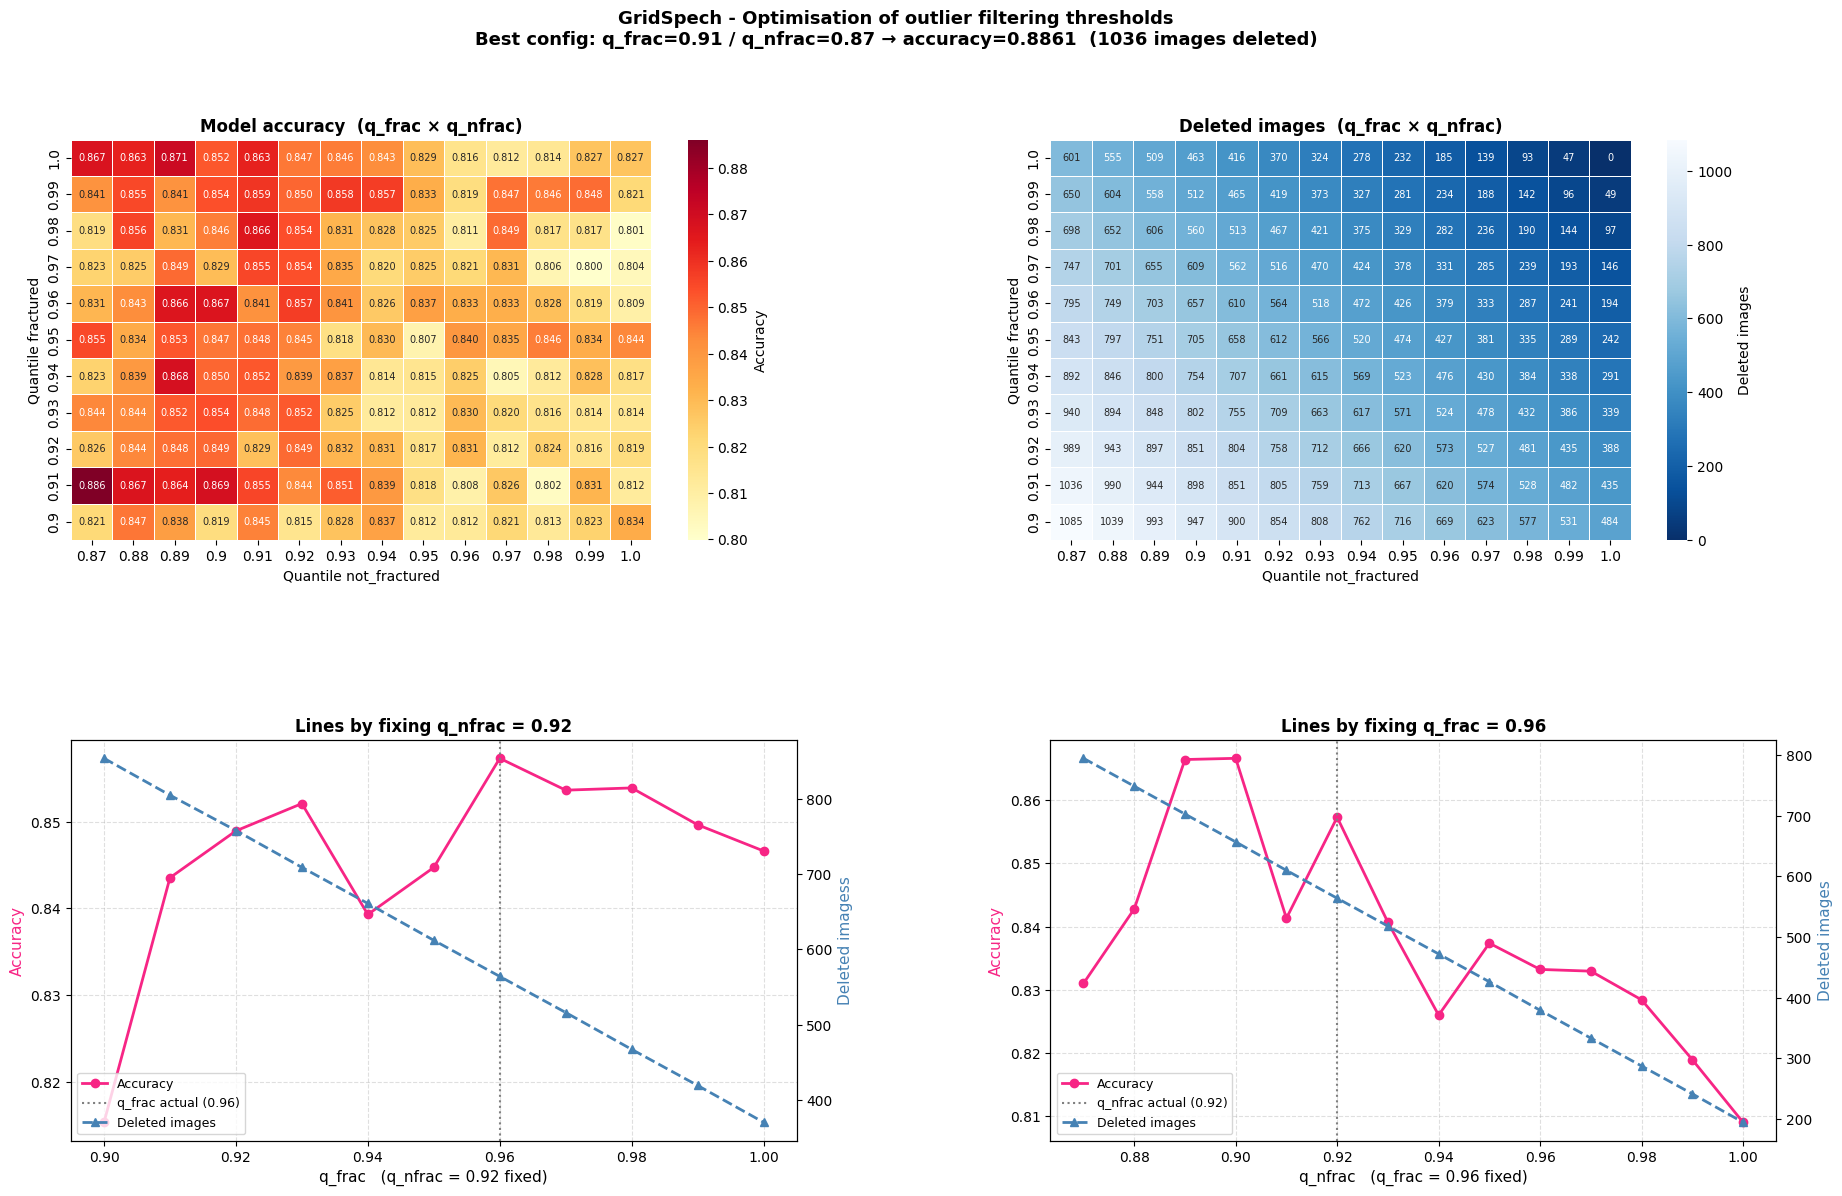

In [14]:
fig = plt.figure(figsize=(22, 13))
layout = GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.35)

ax1 = fig.add_subplot(layout[0, 0])
pivot_acc = gs_df.pivot(index='q_frac', columns='q_nfrac', values='accuracy')
pivot_acc = pivot_acc.sort_index(ascending=False)
sns.heatmap(pivot_acc, ax=ax1, cmap='YlOrRd', annot=True, fmt='.3f', cbar_kws={'label': 'Accuracy'}, linewidths=0.4, annot_kws={'size': 7})
ax1.set_title('Model accuracy  (q_frac × q_nfrac)', fontweight='bold')
ax1.set_xlabel('Quantile not_fractured')
ax1.set_ylabel('Quantile fractured')


ax2 = fig.add_subplot(layout[0, 1])
pivot_rem = gs_df.pivot(index='q_frac', columns='q_nfrac', values='total_removed')
pivot_rem = pivot_rem.sort_index(ascending=False)
sns.heatmap(pivot_rem, ax=ax2, cmap='Blues_r', annot=True, fmt='.0f', cbar_kws={'label': 'Deleted images'}, linewidths=0.4, annot_kws={'size': 7})
ax2.set_title("Deleted images  (q_frac × q_nfrac)", fontweight='bold')
ax2.set_xlabel('Quantile not_fractured')
ax2.set_ylabel('Quantile fractured')


ax3 = fig.add_subplot(layout[1, 0])
ax3b = ax3.twinx()
sub3 = gs_df[gs_df['q_nfrac'].round(2) == 0.92].sort_values('q_frac')
l1, = ax3.plot(sub3['q_frac'],  sub3['accuracy'], color=palette[0], marker='o', lw=2, label='Accuracy')
l2, = ax3b.plot(sub3['q_frac'], sub3['total_removed'], color='steelblue', marker='^', lw=2, linestyle='--', label='Deleted images')
ax3.axvline(0.96, color='gray', linestyle=':', lw=1.5, label='q_frac actual (0.96)')

ax3.set_xlabel('q_frac   (q_nfrac = 0.92 fixed)', fontsize=11)
ax3.set_ylabel('Accuracy', color=palette[0], fontsize=11)
ax3b.set_ylabel('Deleted imagess', color='steelblue', fontsize=11)
ax3.set_title('Lines by fixing q_nfrac = 0.92', fontweight='bold')
lns3 = ax3.get_lines() + ax3b.get_lines()
ax3.legend(lns3, [l.get_label() for l in lns3], loc='lower left', fontsize=9)
ax3.grid(True, linestyle='--', alpha=0.4)


ax4 = fig.add_subplot(layout[1, 1])
ax4b = ax4.twinx()
sub4 = gs_df[gs_df['q_frac'].round(2) == 0.96].sort_values('q_nfrac')
l3, = ax4.plot(sub4['q_nfrac'],  sub4['accuracy'], color=palette[0], marker='o', lw=2, label='Accuracy')
l4, = ax4b.plot(sub4['q_nfrac'], sub4['total_removed'], color='steelblue', marker='^', lw=2, linestyle='--', label='Deleted images')
ax4.axvline(0.92, color='gray', linestyle=':', lw=1.5, label='q_nfrac actual (0.92)')

ax4.set_xlabel('q_nfrac   (q_frac = 0.96 fixed)', fontsize=11)
ax4.set_ylabel('Accuracy', color=palette[0], fontsize=11)
ax4b.set_ylabel('Deleted images', color='steelblue', fontsize=11)
ax4.set_title('Lines by fixing q_frac = 0.96', fontweight='bold')
lns4 = ax4.get_lines() + ax4b.get_lines()
ax4.legend(lns4, [l.get_label() for l in lns4], loc='lower left', fontsize=9)
ax4.grid(True, linestyle='--', alpha=0.4)


best_row = gs_df.loc[gs_df['accuracy'].idxmax()]
plt.suptitle(f'GridSpech - Optimisation of outlier filtering thresholds\nBest config: q_frac={best_row["q_frac"]:.2f} / q_nfrac={best_row["q_nfrac"]:.2f} → accuracy={best_row["accuracy"]:.4f}  ({int(best_row["total_removed"])} images deleted)', fontsize=13, fontweight='bold')
plt.show()

**Now that we know our best quantiles are : `q_nfrac = 0.92 and q_frac = 0.96`, we can delete the outliers.**

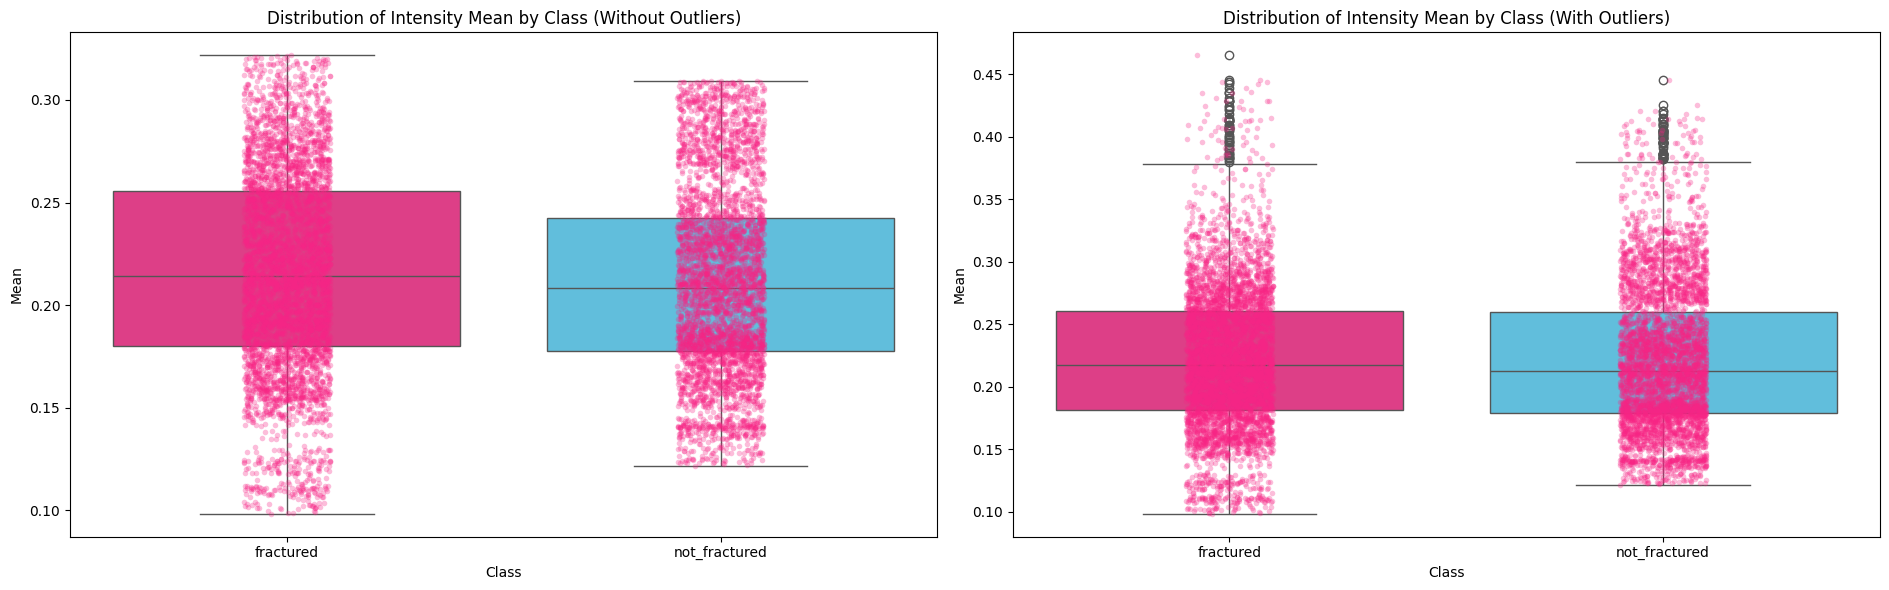

Number of filtered images in 'fractured' class: 194
Number of filtered images in 'not_fractured' class: 370


In [15]:
max_mean_fractured = df[df['Class'] == 'fractured']['Mean'].quantile(0.96)
max_mean_not_fractured = df[df['Class'] == 'not_fractured']['Mean'].quantile(0.92)
filtered_df = df[((df['Class'] == 'fractured') & (df['Mean'] <= max_mean_fractured)) | ((df['Class'] == 'not_fractured') & (df['Mean'] <= max_mean_not_fractured))]

fig, axes = plt.subplots(1, 2, figsize=(19, 6))
sns.boxplot(data=filtered_df, x='Class', y='Mean', hue='Class', palette=palette, ax=axes[0], legend=False)
sns.stripplot(data=filtered_df, x='Class', y='Mean', color=colors[0], alpha=0.3, size=4, ax=axes[0])
axes[0].set_title('Distribution of Intensity Mean by Class (Without Outliers)')
sns.boxplot(data=df, x='Class', y='Mean', hue='Class', palette=palette, ax=axes[1], legend=False)
sns.stripplot(data=df, x='Class', y='Mean', color=colors[0], alpha=0.3, size=4, ax=axes[1])
axes[1].set_title('Distribution of Intensity Mean by Class (With Outliers)')
plt.tight_layout()
plt.show()

num_filtered_fractured = len(df[(df['Class'] == 'fractured') & (df['Mean'] > max_mean_fractured)])
num_filtered_not_fractured = len(df[(df['Class'] == 'not_fractured') & (df['Mean'] > max_mean_not_fractured)])
print(f"Number of filtered images in 'fractured' class: {num_filtered_fractured}")
print(f"Number of filtered images in 'not_fractured' class: {num_filtered_not_fractured}")
                                            

### Images transformation :

**A quick explanation of the bilinear interpolation implemented:** 

<div style="display: flex; align-items: center; gap: 20px;">



<div style="flex: 1;">
<img src="assets/images/interpol_schematics.png" width="800">
</div>


<div style="flex: 1;">

**There are 4 steps in our interpolation :**

The box plot displays the distribution of data using five summary statistics:

- **Coordinate calculation** -> The code projects the new pixels onto the old grid and identifies the two nearest neighbors (i0 and i1) as well as the distance between them (weights).
- **Horizontal interpolation** -> For each row, the code creates an intermediate version of the image by blending the colors of the left and right neighbors according to the weight dx.
- **Vertical interpolation** -> Starting from this intermediate image, the code blends the top and bottom rows according to the weight dy to obtain the final position.
- **Finalization** -> The result is converted to 32-bit floating-point numbers to ensure smooth gradient accuracy during downscaling.


*There are many interpolation techniques, such as nearest neighbors or area interpolation. But after comparison, the bilinear method offers the best balance of time and efficiency.*

</div>


</div>

In [16]:
def load_fracture_dataset(directory, label_value, target_size=(img_size[0], img_size[1]), allowed_names=None):
    files = [f for f in os.listdir(directory) if f.lower().endswith(img_extension)]
    if allowed_names is not None:
        files = [f for f in files if f in allowed_names]
    n_files = len(files)
    print(f"Loading {n_files} files from {directory} with label {label_value}")
    data = np.zeros((n_files, target_size[0], target_size[1]), dtype=np.float32)
    labels = np.full(n_files, label_value, dtype=np.int8)
    pipeline = build_image_pipeline(target_size=target_size)
    for i, f in enumerate(files):
        full_path = os.path.join(directory, f)
        try:
            data[i] = pipeline.fit_transform(full_path)
            # data[i] = preprocess_image(full_path, target_size=target_size) __last version__
        except Exception as e:
            print(f"Errors in the {f}: {e}")
    return data, labels

**Load the dataset from the folders, applying the pipeline to each image. We will have two arrays: one for the fractured images and one for the not fractured images, with their corresponding labels.**

Once the dataset is loaded in X and y, we will concatenate the two arrays to have a single dataset and a single array of labels. We will also print the shape of X before flattening to check that the images are correctly loaded and preprocessed.

In [17]:
fractured_names = set(filtered_df[filtered_df['Class'] == 'fractured']['Name'])
not_fractured_names = set(filtered_df[filtered_df['Class'] == 'not_fractured']['Name'])

X_fractured, y_fractured = load_fracture_dataset('Dataset/fractured/', label_value=1, allowed_names=fractured_names)
X_not_fractured, y_not_fractured = load_fracture_dataset('Dataset/not_fractured/', label_value=0, allowed_names=not_fractured_names)

X = np.concatenate([X_fractured, X_not_fractured], axis=0)
y = np.concatenate([y_fractured, y_not_fractured], axis=0)

print(f"Structure of X after flatten : {X.shape}")


Loading 4646 files from Dataset/fractured/ with label 1
Loading 4253 files from Dataset/not_fractured/ with label 0
Structure of X after flatten : (8899, 224, 224)


**Flatten the images in X to have a 2D array where each row corresponds to an image and each column corresponds to a pixel value. This is necessary for the model to be able to process the data.**

We will also print the shape of X after flattening to check that the images are correctly flattened.

In [18]:
X_flat = flatten_image_array(X)

print(f"Structure of X after flatten : {X_flat.shape}")

Structure of X after flatten : (8899, 50176)



## 3. Model Training and Evaluation

**Import the necessary libraries from `scikit-learn` to train and evaluate the model.**

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

**Split dataset in 80/20, 80% to train and 20% to test, shuffled equally with stratify**

This train/test split can then be optimized with cross-validation.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=5, stratify=y)

### GridSearch on the dataset to find the best model to use
- Output of this will be the best hyperparameter to use for this model. We compare different estimators, tree depth, sample plit to get the best RFC possible

- We tested on RandomForestClassifier model and SVM 

In [21]:
# param_grid_rf = {
#    'n_estimators': [100, 300, 500],
#    'max_depth': [5, 20],
#    'min_samples_split': [2, 5, 10],
#    'class_weight': [None]
# }

# grid_rf = GridSearchCV(RandomForestClassifier(random_state=0), param_grid_rf, cv=5, scoring='f1', n_jobs=12)

# grid_rf.fit(X_train, y_train)

# print(f"Best RF Params: {grid_rf.best_params_}")
# print(f"Best RF F1-Score: {grid_rf.best_score_}")

# best_model = grid_rf.best_estimator_

In [22]:
# y_prediction = best_model.predict(X_test)
# print(confusion_matrix(y_test, y_prediction))
# print(classification_report(y_test, y_prediction))

**Here we can found the confusion matrix and the classification report on the best model outed by the GridSearch**

We've got a near perfect score with only 2 false positive and 4 false Negative

**This GridSearch on SVM model is not worth the compute time (+2000 min of compute) since we got 0,9973 accuracy on random forest**

In [23]:
# param_grid_svm = {
#     'C': [0.1, 1, 10, 100],
#     'gamma': ['scale', 0.001, 0.0001],
#     'kernel': ['rbf', 'poly']
# }

# grid_svm = GridSearchCV(SVC(probability=True), param_grid_svm, cv=5, scoring='f1')
# grid_svm.fit(X_train, y_train)

# print(f"Best SVM Params: {grid_svm.best_params_}")
# print(f"Best SVM Recall: {grid_svm.best_score_}")

# best_svm_model = grid_svm.best_estimator_

In [24]:
# y_prediction = best_svm_model.predict(X_test)
# print(confusion_matrix(y_test, y_prediction))
# print(classification_report(y_test, y_prediction))

### Train on best Model and gives scores

In [25]:
model = RandomForestClassifier(n_estimators=100, max_depth=20, n_jobs=-1, min_samples_split=2, class_weight=None, )

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
y_prediction = model.predict(X_test)

print("Accuracy Score:", accuracy)
print(f"Fractured samples: {len(y_fractured)}")
print(f"Not fractured samples: {len(y_not_fractured)}")
print(confusion_matrix(y_test, y_prediction))
print(classification_report(y_test, y_prediction))

Accuracy Score: 0.9955056179775281
Fractured samples: 4646
Not fractured samples: 4253
[[849   2]
 [  6 923]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       851
           1       1.00      0.99      1.00       929

    accuracy                           1.00      1780
   macro avg       1.00      1.00      1.00      1780
weighted avg       1.00      1.00      1.00      1780

